# SIH26158 - HF Drone full 253-frame geometry before/after experiment

This notebook downloads the native ~4.2-minute DJI Mini 4 Pro MP4 and matching flight record from [`npeng/drone-telemetry`](https://huggingface.co/datasets/npeng/drone-telemetry/tree/main). It uses the full 253-keyframe, 1920-pixel configuration associated with the earlier ~80-minute run. It executes a controlled baseline, a geometry-aware GPS-pose-prior variant at the same frame count and dense workload, and a fast variant that computes dense depth on every second reference view. It then reports whether either updated method is faster than both the new controlled baseline and the historical 80.75-minute result.

Before running, select **Runtime > Change runtime type > T4 GPU**. Run cells in order. The Conda cell restarts the runtime once; continue from Cell 3 after that restart.

Evidence boundary: this public dataset has GPS but no independent surveyed surface truth. It can demonstrate the full system, but it cannot alone prove the SIH `<=1 m` surface-accuracy target. The report leaves that target unevaluated until real checkpoints are supplied. Unseen/occluded geometry is never claimed as measured.

In [1]:
# CELL 1 - mount Drive, locate the extracted package, and require a GPU
import os, subprocess
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB'
assert os.path.isfile(f'{PROJECT_DIR}/requirements.txt'), (
    f'Project not found at {PROJECT_DIR}. Extract the ZIP to exactly MyDrive/SIH26158_HF_Drone_Full253_AB.'
)
gpu = subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True,
)
assert gpu.returncode == 0, 'No NVIDIA GPU detected. Select a T4 GPU runtime.'
print('GPU:', gpu.stdout.strip())
print('Project:', PROJECT_DIR)

Mounted at /content/drive
GPU: Tesla T4, 15360 MiB
Project: /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB


In [2]:
# CELL 2 - install Conda (runs once and intentionally restarts the runtime)
# After the automatic restart, continue at CELL 3. Do not rerun this cell.
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
# CELL 3 - install CUDA-capable COLMAP and Python dependencies, then test the package
import os, shutil, subprocess, sys
from google.colab import drive

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB'
assert shutil.which('mamba'), 'Conda is missing. Run CELL 2 and wait for its restart.'
pin = '/usr/local/conda-meta/pinned'
if os.path.exists(pin):
    os.remove(pin)
subprocess.run(
    ['mamba', 'install', '-y', '-q', '-c', 'conda-forge', 'colmap', 'libfaiss', 'openimageio'],
    check=True,
)
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-r', f'{PROJECT_DIR}/requirements.txt'],
    check=True,
)
check = subprocess.run(['colmap', '-h'], capture_output=True, text=True, errors='replace')
header = (check.stdout or '') + (check.stderr or '')
print('\n'.join(header.splitlines()[:10]))
assert check.returncode == 0 and 'COLMAP' in header, 'COLMAP does not run.'
assert 'CUDA' in header and 'WITHOUT CUDA' not in header.upper(), 'COLMAP is not CUDA-enabled.'
assert 'pose_prior_mapper' in header, 'Install a current COLMAP build with pose_prior_mapper.'
subprocess.run(
    [sys.executable, '-m', 'unittest', 'discover', '-s', 'tests', '-v'],
    cwd=PROJECT_DIR, check=True,
)
print('Installation and tests complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
COLMAP 4.2.0 (Commit Unknown on Unknown with CUDA)
Usage:
  colmap [command] [options]
Documentation:
  https://colmap.github.io/
Example usage:
  colmap help [ -h, --help ]
  colmap gui
  colmap gui -h [ --help ]
  colmap automatic_reconstructor -h [ --help ]
Installation and tests complete.


In [2]:
# CELL 4 - download the two source files and normalize DJI telemetry
import json, os, subprocess, sys

PROJECT_DIR = '/content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB'
DATA_DIR = '/content/hf_drone_dataset'          # fast, temporary Colab storage
PREPARED_DIR = '/content/hf_drone_prepared'
VIDEO = f'{DATA_DIR}/20240629164410_0023_D.mp4'
TELEMETRY = f'{PREPARED_DIR}/hf_drone_telemetry.csv'

env = os.environ.copy()
env['PYTHONPATH'] = PROJECT_DIR + os.pathsep + env.get('PYTHONPATH', '')
prepare = [
    sys.executable, '-m', 'sih_drone_pipeline.dataset',
    '--dataset', 'hf-drone', '--download-dir', DATA_DIR, '--output', PREPARED_DIR,
]
subprocess.run(prepare, cwd=PROJECT_DIR, env=env, check=True)
manifest = json.load(open(f'{PREPARED_DIR}/dataset_manifest.json'))

probe = subprocess.run([
    'ffprobe', '-v', 'error', '-select_streams', 'v:0',
    '-show_entries', 'stream=width,height,r_frame_rate,nb_frames:format=duration',
    '-of', 'json', VIDEO,
], capture_output=True, text=True, check=True)
video_info = json.loads(probe.stdout)
stream = video_info['streams'][0]
duration_s = float(video_info['format']['duration'])
manifest['video_probe'] = video_info
json.dump(manifest, open(f'{PREPARED_DIR}/dataset_manifest.json', 'w'), indent=2)

assert int(stream['height']) >= 1080, f"Expected 1080p/4K input, got {stream['width']}x{stream['height']}"
delta = abs(duration_s - float(manifest['telemetry_duration_s']))
assert delta <= max(2.0, 0.02 * duration_s), f'Video/telemetry duration mismatch: {delta:.2f} s'
print(json.dumps({
    'resolution': f"{stream['width']}x{stream['height']}",
    'video_duration_s': duration_s,
    'telemetry_duration_s': manifest['telemetry_duration_s'],
    'telemetry_samples': manifest['telemetry_samples'],
    'recording_segments_found': manifest['recording_segments_found'],
    'selected_segment': manifest['selected_segment_policy'],
    'gps_satellites_median': manifest['gps_satellites_median'],
}, indent=2))

{
  "resolution": "1920x1080",
  "video_duration_s": 251.517933,
  "telemetry_duration_s": 252.4,
  "telemetry_samples": 2525,
  "recording_segments_found": 2,
  "selected_segment": "longest_continuous_CAMERA.isVideo_interval",
  "gps_satellites_median": 25.0
}


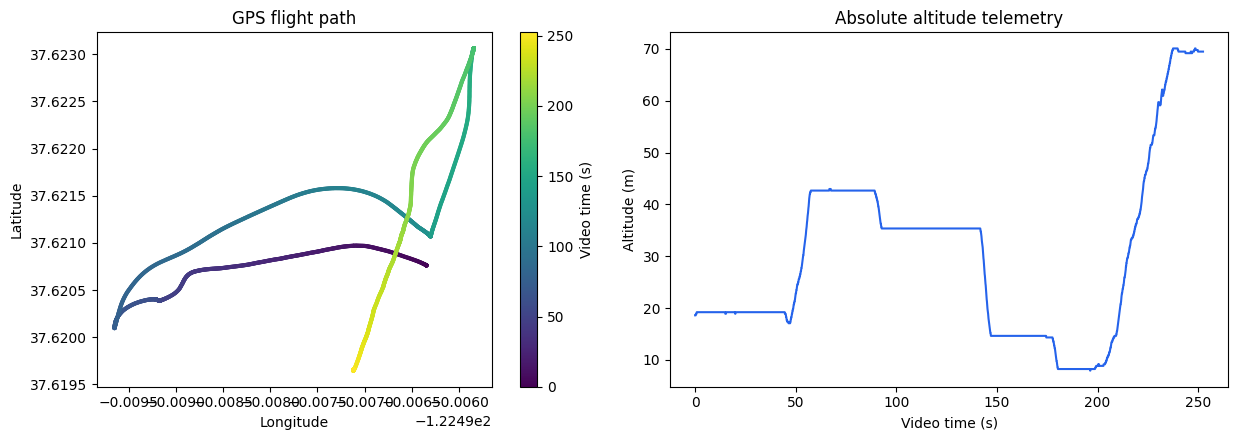

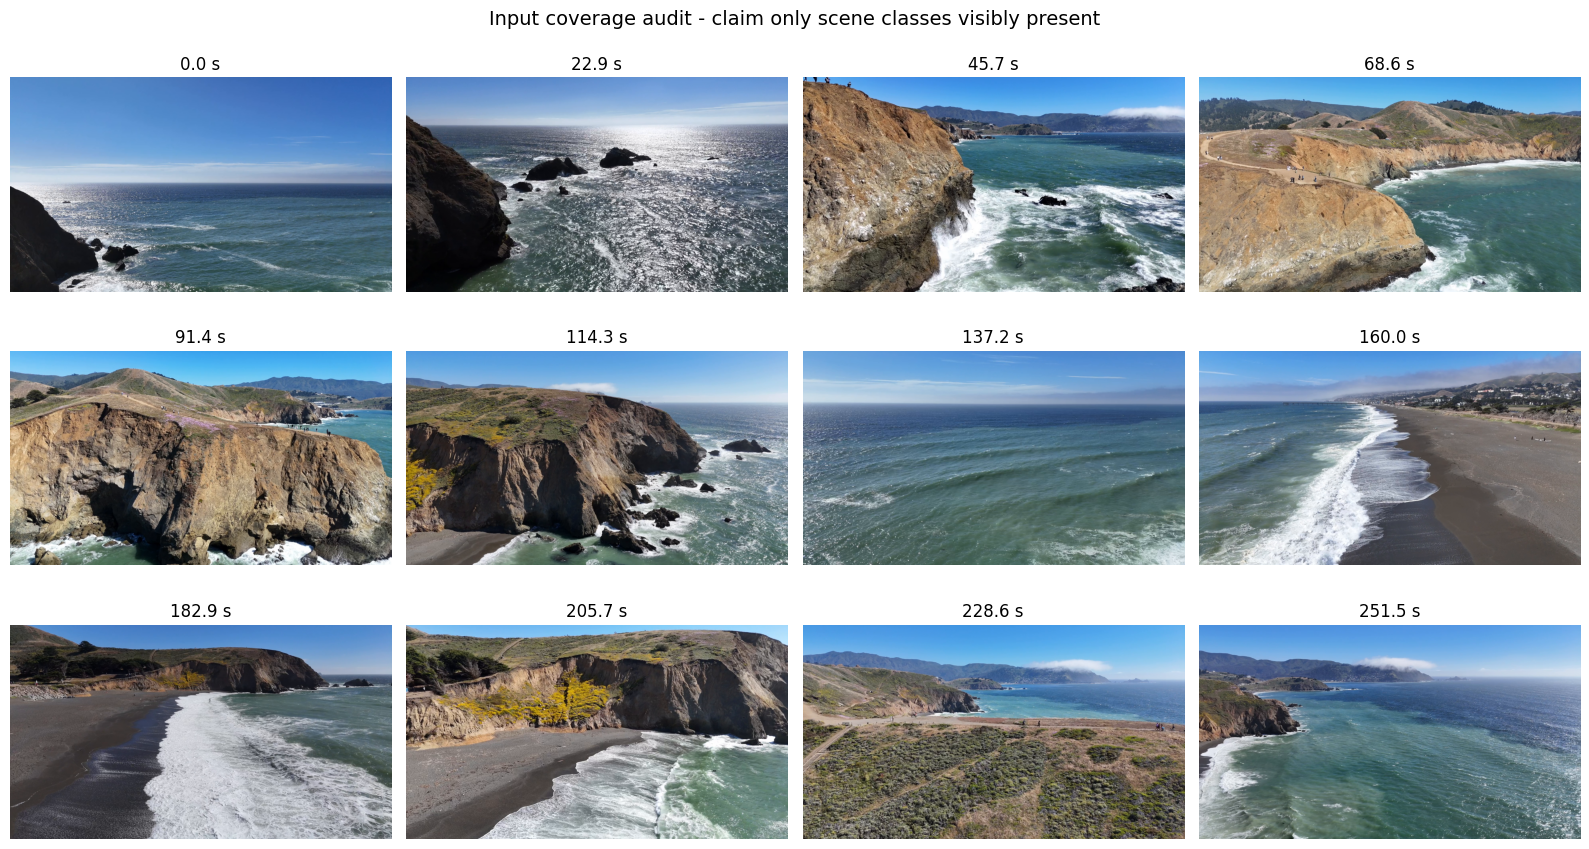

Experiment root: /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/outputs/full253_geometry_ab
Independent checkpoints: optional per-run CSVs; otherwise <=1 m surface accuracy remains unevaluated


In [3]:
# CELL 5 - configure a controlled before/after experiment and inspect input coverage
import csv, json, math, os
from fractions import Fraction
import cv2
import matplotlib.pyplot as plt
import numpy as np

EXPERIMENTS = [
    {
        'name': 'full253_before_uniform',
        'keyframe_mode': 'uniform',
        'mapper': 'standard',
        'dense_frame_stride': 1,
    },
    {
        'name': 'full253_after_geometry_quality',
        'keyframe_mode': 'geometry',
        'mapper': 'pose-prior',
        'dense_frame_stride': 1,
    },
    {
        'name': 'full253_after_geometry_fast',
        'keyframe_mode': 'geometry',
        'mapper': 'pose-prior',
        'dense_frame_stride': 2,
    },
]
QUALITY = 'draft'
TARGET_FRAMES = 253               # full approximately one-keyframe-per-second set
MAX_WIDTH = 1920                  # matches the earlier approximately 80-minute run
DSM_RESOLUTION_M = 0.5
GPS_PRIOR_STD_M = 5.0             # consumer GPS uncertainty, not RTK accuracy
AI_MASK_DYNAMIC_OBJECTS = False   # held constant to isolate geometry changes
RESET_WORKSPACE = True
REUSE_COMPLETED_OUTPUTS = True    # safe resume after a Colab disconnect
CLEAN_WORKSPACE_AFTER_RUN = True  # prevents three dense workspaces filling Colab disk
HISTORICAL_RUNTIME_MIN = 80.75    # earlier 253-frame result; controlled rerun remains primary
# Optional checkpoint files are per reconstruction because each model has its own measured XYZ.
CHECKPOINT_TEMPLATE = f'{PROJECT_DIR}/validation_checkpoints_{{run_name}}.csv'
EXPERIMENT_ROOT = f'{PROJECT_DIR}/outputs/full253_geometry_ab'
os.makedirs(f'{EXPERIMENT_ROOT}/input_evidence', exist_ok=True)

# Flight path and altitude audit.
rows = list(csv.DictReader(open(TELEMETRY, encoding='utf-8')))
t = np.array([float(row['time_s']) for row in rows])
lat = np.array([float(row['latitude']) for row in rows])
lon = np.array([float(row['longitude']) for row in rows])
alt = np.array([float(row['altitude_m']) for row in rows])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
route = axes[0].scatter(lon, lat, c=t, s=4, cmap='viridis')
axes[0].set(title='GPS flight path', xlabel='Longitude', ylabel='Latitude', aspect='equal')
fig.colorbar(route, ax=axes[0], label='Video time (s)')
axes[1].plot(t, alt, color='#2563eb')
axes[1].set(title='Absolute altitude telemetry', xlabel='Video time (s)', ylabel='Altitude (m)')
fig.tight_layout()
fig.savefig(f'{EXPERIMENT_ROOT}/input_evidence/telemetry_audit.png', dpi=160)
plt.show()

# Twelve evenly spaced source frames expose scene classes, viewing angles, blur, and lighting.
cap = cv2.VideoCapture(VIDEO)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
source_fps = float(Fraction(stream['r_frame_rate']))
indices = np.linspace(0, max(frame_count - 1, 0), 12).astype(int)
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for axis, frame_index in zip(axes.flat, indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_index))
    ok, frame = cap.read()
    if ok:
        axis.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axis.set_title(f'{frame_index / source_fps:.1f} s')
    axis.axis('off')
cap.release()
fig.suptitle('Input coverage audit - claim only scene classes visibly present', fontsize=14)
fig.tight_layout()
fig.savefig(
    f'{EXPERIMENT_ROOT}/input_evidence/source_contact_sheet.jpg', dpi=150,
    pil_kwargs={'quality': 90},
)
plt.show()

print('Experiment root:', EXPERIMENT_ROOT)
print('Independent checkpoints: optional per-run CSVs; otherwise <=1 m surface accuracy remains unevaluated')

In [7]:
# CELL 6 - run the controlled baseline and geometry experiment
import json, os, shutil, subprocess, sys, time

env = os.environ.copy()
env['PYTHONPATH'] = PROJECT_DIR + os.pathsep + env.get('PYTHONPATH', '')

completed_outputs = []
for experiment in EXPERIMENTS:
    run_name = experiment['name']
    workspace = f'/content/sih26158_{run_name}'
    output = f'{EXPERIMENT_ROOT}/{run_name}'
    os.makedirs(output, exist_ok=True)
    if REUSE_COMPLETED_OUTPUTS and os.path.isfile(f'{output}/run_report.json'):
        verify_existing = [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', output]
        if subprocess.run(verify_existing, cwd=PROJECT_DIR, env=env).returncode == 0:
            print(f'Reusing verified completed run: {run_name}')
            completed_outputs.append(output)
            continue
    if RESET_WORKSPACE and os.path.isdir(workspace):
        shutil.rmtree(workspace)

    preflight = [
        sys.executable, '-m', 'sih_drone_pipeline', 'preflight',
        '--video', VIDEO, '--telemetry', TELEMETRY, '--workspace', workspace,
        '--output', f'{output}/preflight.json',
    ]
    assert subprocess.run(preflight, cwd=PROJECT_DIR, env=env).returncode == 0

    command = [
        sys.executable, '-m', 'sih_drone_pipeline', 'run',
        '--video', VIDEO, '--telemetry', TELEMETRY,
        '--workspace', workspace, '--output', output,
        '--quality', QUALITY, '--target-frames', str(TARGET_FRAMES),
        '--max-width', str(MAX_WIDTH), '--dsm-resolution', str(DSM_RESOLUTION_M),
        '--keyframe-mode', experiment['keyframe_mode'],
        '--mapper', experiment['mapper'],
        '--gps-prior-std-m', str(GPS_PRIOR_STD_M),
        '--dense-frame-stride', str(experiment['dense_frame_stride']),
    ]
    if AI_MASK_DYNAMIC_OBJECTS:
        command.append('--ai-mask-dynamic')
    checkpoints = CHECKPOINT_TEMPLATE.format(run_name=run_name)
    if os.path.isfile(checkpoints):
        command += ['--validation-checkpoints', checkpoints]

    stop_file = f'/content/{run_name}.gpu.stop'
    if os.path.exists(stop_file):
        os.remove(stop_file)
    monitor = subprocess.Popen([
        sys.executable, '-m', 'sih_drone_pipeline.gpu_monitor',
        '--output', f'{output}/gpu_usage.csv', '--stop-file', stop_file,
    ], cwd=PROJECT_DIR, env=env)
    print('\nRunning:', ' '.join(command))
    started = time.time()
    try:
        result = subprocess.run(command, cwd=PROJECT_DIR, env=env)
    finally:
        open(stop_file, 'w').close()
        monitor.wait(timeout=20)
        if os.path.isdir(f'{workspace}/logs'):
            shutil.copytree(f'{workspace}/logs', f'{output}/logs', dirs_exist_ok=True)
        partial = f'{workspace}/run_report.partial.json'
        if os.path.isfile(partial):
            shutil.copy2(partial, f'{output}/run_report.partial.json')
    print(f'{run_name}: {(time.time() - started) / 60:.2f} minutes')
    assert result.returncode == 0, f'{run_name} failed; inspect its logs.'
    shutil.copy2(f'{PREPARED_DIR}/dataset_manifest.json', f'{output}/dataset_manifest.json')
    verify = [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', output]
    assert subprocess.run(verify, cwd=PROJECT_DIR, env=env).returncode == 0
    completed_outputs.append(output)
    if CLEAN_WORKSPACE_AFTER_RUN and os.path.isdir(workspace):
        shutil.rmtree(workspace)

BEFORE_OUTPUT, AFTER_QUALITY_OUTPUT, AFTER_FAST_OUTPUT = completed_outputs
OUTPUT = AFTER_QUALITY_OUTPUT

Reusing verified completed run: full253_before_uniform
Reusing verified completed run: full253_after_geometry_quality

Running: /usr/bin/python3.real -m sih_drone_pipeline run --video /content/hf_drone_dataset/20240629164410_0023_D.mp4 --telemetry /content/hf_drone_prepared/hf_drone_telemetry.csv --workspace /content/sih26158_full253_after_geometry_fast --output /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/outputs/full253_geometry_ab/full253_after_geometry_fast --quality draft --target-frames 253 --max-width 1920 --dsm-resolution 0.5 --keyframe-mode geometry --mapper pose-prior --gps-prior-std-m 5.0 --dense-frame-stride 2
full253_after_geometry_fast: 52.66 minutes


quality runtime speedup: 1.038132663102742
NOT EVALUATED: both runs need the same independent surveyed checkpoints; reprojection and GPS residual do not prove surface accuracy.
fast runtime speedup: 1.4834581179689876
NOT EVALUATED: both runs need the same independent surveyed checkpoints; reprojection and GPS residual do not prove surface accuracy.


,variant,metric,before,after,change_percent
0,quality,wall_clock_seconds,4.683930e+03,4.511880e+03,-3.673198
1,quality,input_frames,2.530000e+02,2.530000e+02,0.000000
2,quality,registered_images,2.070000e+02,2.070000e+02,0.000000
3,quality,registration_percent,8.182000e+01,8.182000e+01,0.000000
4,quality,reprojection_error_px,4.421610e-01,4.525390e-01,2.347109
5,quality,gps_alignment_rmse_m,1.842806e+00,1.825406e+00,-0.944210
6,quality,point_count,1.143877e+06,1.168180e+06,2.124617
7,quality,dsm_valid_fraction,1.095963e-01,1.098835e-01,0.262016
8,quality,mesh_vertices,3.015630e+05,3.075150e+05,1.973717
9,quality,mesh_faces,6.030810e+05,6.144330e+05,1.882334


,variant,runtime_minutes,minutes_vs_historical_80_75,faster_than_historical_80_75
0,controlled_baseline,78.07,-2.68,True
1,geometry_quality,75.20,-5.55,True
2,geometry_fast,52.62,-28.13,True


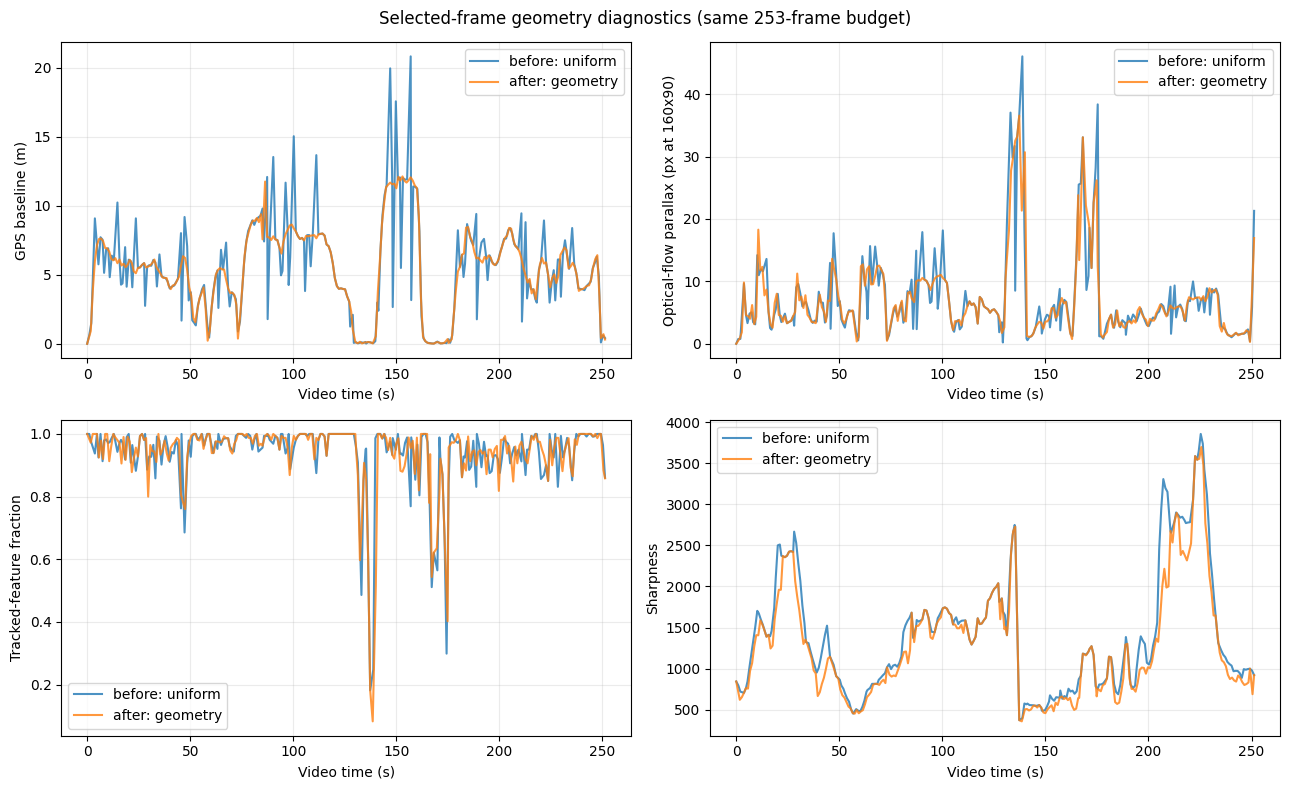

Reports and geometry diagnostic saved under: /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/outputs/full253_geometry_ab


In [8]:
# CELL 7 - generate the machine-readable and readable A/B comparison
import json, subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd

comparisons = [
    ('quality', AFTER_QUALITY_OUTPUT),
    ('fast', AFTER_FAST_OUTPUT),
]
all_rows = []
for label, after_output in comparisons:
    comparison_json = f'{EXPERIMENT_ROOT}/comparison_{label}.json'
    compare = [
        sys.executable, '-m', 'sih_drone_pipeline', 'compare',
        '--before', BEFORE_OUTPUT, '--after', after_output, '--output', comparison_json,
    ]
    assert subprocess.run(compare, cwd=PROJECT_DIR, env=env).returncode == 0
    comparison = json.load(open(comparison_json))
    for metric, values in comparison['metrics'].items():
        all_rows.append({
            'variant': label, 'metric': metric, 'before': values['before'],
            'after': values['after'], 'change_percent': values['change_percent'],
        })
    print(label, 'runtime speedup:', comparison['speedup'])
    print(comparison['surface_accuracy_note'])
comparison_table = pd.DataFrame(all_rows)
display(comparison_table)
comparison_table.to_csv(f'{EXPERIMENT_ROOT}/comparison_metrics.csv', index=False)
runtime_rows = []
for label, output in [('controlled_baseline', BEFORE_OUTPUT),
                      ('geometry_quality', AFTER_QUALITY_OUTPUT),
                      ('geometry_fast', AFTER_FAST_OUTPUT)]:
    seconds = json.load(open(f'{output}/run_report.json'))['wall_clock_seconds']
    minutes = seconds / 60.0
    runtime_rows.append({
        'variant': label, 'runtime_minutes': round(minutes, 2),
        'minutes_vs_historical_80_75': round(minutes - HISTORICAL_RUNTIME_MIN, 2),
        'faster_than_historical_80_75': minutes < HISTORICAL_RUNTIME_MIN,
    })
runtime_table = pd.DataFrame(runtime_rows)
display(runtime_table)
runtime_table.to_csv(f'{EXPERIMENT_ROOT}/runtime_vs_historical_80_75.csv', index=False)

# Show whether the selector actually changed temporal-stereo geometry.
before_frames = pd.read_csv(f'{BEFORE_OUTPUT}/frames.csv')
geometry_frames = pd.read_csv(f'{AFTER_QUALITY_OUTPUT}/frames.csv')
diagnostics = [
    ('baseline_m', 'GPS baseline (m)'),
    ('parallax_px', 'Optical-flow parallax (px at 160x90)'),
    ('tracked_fraction', 'Tracked-feature fraction'),
    ('sharpness', 'Sharpness'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for axis, (column, label) in zip(axes.ravel(), diagnostics):
    axis.plot(before_frames['time_s'], before_frames[column], label='before: uniform', alpha=0.8)
    axis.plot(geometry_frames['time_s'], geometry_frames[column], label='after: geometry', alpha=0.8)
    axis.set(xlabel='Video time (s)', ylabel=label)
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle('Selected-frame geometry diagnostics (same 253-frame budget)')
fig.tight_layout()
diagnostic_plot = f'{EXPERIMENT_ROOT}/keyframe_selection_comparison.png'
fig.savefig(diagnostic_plot, dpi=160, bbox_inches='tight')
plt.show()
print('Reports and geometry diagnostic saved under:', EXPERIMENT_ROOT)

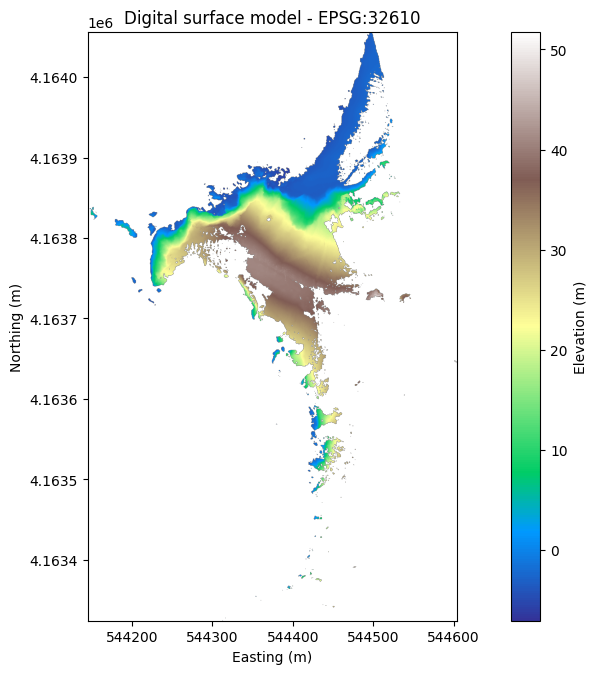

Standalone preview: /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/outputs/full253_geometry_ab/full253_after_geometry_quality/point_cloud_preview.html
For precise two-point measurement, open model.glb and viewer_metadata.json in the bundled viewer.


In [9]:
# CELL 8 - view the GeoTIFF DSM and an interactive metric 3D point-cloud preview
import os
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import rasterio
import trimesh

with rasterio.open(f'{OUTPUT}/dsm.tif') as dataset:
    dsm = dataset.read(1, masked=True)
    bounds, crs = dataset.bounds, dataset.crs
plt.figure(figsize=(11, 7))
plt.imshow(dsm, cmap='terrain', extent=[bounds.left, bounds.right, bounds.bottom, bounds.top], origin='upper')
plt.colorbar(label='Elevation (m)')
plt.title(f'Digital surface model - {crs}')
plt.xlabel('Easting (m)'); plt.ylabel('Northing (m)')
plt.tight_layout(); plt.show()

cloud = trimesh.load(f'{OUTPUT}/point_cloud.ply', process=False)
vertices = np.asarray(cloud.vertices)
rng = np.random.default_rng(26158)
sample = rng.choice(len(vertices), min(50000, len(vertices)), replace=False)
points = vertices[sample]
colors = None
if hasattr(cloud.visual, 'vertex_colors') and len(cloud.visual.vertex_colors) == len(vertices):
    rgba = np.asarray(cloud.visual.vertex_colors)[sample]
    colors = [f'rgb({r},{g},{b})' for r, g, b in rgba[:, :3]]
figure = go.Figure(go.Scatter3d(
    x=points[:, 0], y=points[:, 1], z=points[:, 2], mode='markers',
    marker={'size': 1.2, 'color': colors if colors else points[:, 2], 'colorscale': 'Viridis'},
    hovertemplate='E=%{x:.2f} m<br>N=%{y:.2f} m<br>U=%{z:.2f} m<extra></extra>',
))
figure.update_layout(
    title='Metric ENU point-cloud preview (downsampled for display)',
    scene={'aspectmode': 'data', 'xaxis_title': 'East (m)', 'yaxis_title': 'North (m)', 'zaxis_title': 'Up (m)'},
    height=700,
)
preview = f'{OUTPUT}/point_cloud_preview.html'
figure.write_html(preview, include_plotlyjs=True)
figure.show()
print('Standalone preview:', preview)
print('For precise two-point measurement, open model.glb and viewer_metadata.json in the bundled viewer.')

In [10]:
# CELL 9 - bundle viewers and a compact comparison-evidence archive in Drive
import os, shutil

instructions = '''# View and measure the result\n\n1. Install Node.js 20 or newer.\n2. In this metric_viewer folder run `npm install` then `npm run dev`.\n3. Open the shown local URL.\n4. Load `../model.glb` and `../viewer_metadata.json`.\n5. Shift-click two surface points to measure their distance in metres.\n'''
for output in completed_outputs:
    viewer_target = f'{output}/metric_viewer'
    shutil.copytree(f'{PROJECT_DIR}/sih_drone_pipeline/viewer', viewer_target, dirs_exist_ok=True)
    open(f'{viewer_target}/VIEW_RESULTS.md', 'w', encoding='utf-8').write(instructions)

# Full reconstructions already persist in Drive. Package the small evidence files once,
# avoiding a second multi-GB copy of all point clouds and meshes.
evidence_dir = f'{EXPERIMENT_ROOT}/comparison_evidence'
os.makedirs(evidence_dir, exist_ok=True)
for name in ['comparison_quality.json', 'comparison_quality.md',
             'comparison_fast.json', 'comparison_fast.md',
             'comparison_metrics.csv', 'runtime_vs_historical_80_75.csv',
             'keyframe_selection_comparison.png']:
    source = f'{EXPERIMENT_ROOT}/{name}'
    if os.path.isfile(source):
        shutil.copy2(source, f'{evidence_dir}/{name}')
for output in completed_outputs:
    run_name = os.path.basename(output)
    run_evidence = f'{evidence_dir}/{run_name}'
    os.makedirs(run_evidence, exist_ok=True)
    for name in ['run_report.json', 'verification_report.json', 'preflight.json',
                 'frames.csv', 'frames.selection.json', 'gpu_usage.csv', 'dataset_manifest.json']:
        source = f'{output}/{name}'
        if os.path.isfile(source):
            shutil.copy2(source, f'{run_evidence}/{name}')
archive = shutil.make_archive(f'{EXPERIMENT_ROOT}/full253_geometry_ab_evidence', 'zip', evidence_dir)
print('Evidence archive:', archive)
print(f'Archive size: {os.path.getsize(archive) / 1024 / 1024:.1f} MB')
print('Full point clouds, DSMs and meshes remain in each experiment output directory.')

Evidence archive: /content/drive/MyDrive/SIH26158_HF_Drone_Full253_AB/outputs/full253_geometry_ab/full253_geometry_ab_evidence.zip
Archive size: 0.6 MB
Full point clouds, DSMs and meshes remain in each experiment output directory.


In [11]:
# CELL 10 - optional: attach surveyed <=1 m evidence later without rerunning reconstruction
# Create one checkpoint CSV per run from examples/validation_checkpoints.example.csv.
# The surveyed known XYZ stays identical, but reconstructed XYZ must be measured separately
# from each run's model. Then rerun CELL 7 to refresh the comparisons.
import os, subprocess, sys

validated = 0
for output in completed_outputs:
    run_name = os.path.basename(output)
    checkpoints = f'{PROJECT_DIR}/validation_checkpoints_{run_name}.csv'
    if not os.path.isfile(checkpoints):
        print(f'{run_name}: no checkpoint CSV; surface accuracy remains NOT EVALUATED.')
        continue
    completed = subprocess.run([
        sys.executable, '-m', 'sih_drone_pipeline', 'validate-checkpoints',
        '--output', output, '--checkpoints', checkpoints,
    ], cwd=PROJECT_DIR, env=env)
    print(f'{run_name}:', 'checkpoint gate passed' if completed.returncode == 0 else 'checkpoint gate failed')
    subprocess.run(
        [sys.executable, '-m', 'sih_drone_pipeline', 'verify', '--output', output],
        cwd=PROJECT_DIR, env=env,
    )
    validated += 1
print(f'Validated {validated}/{len(completed_outputs)} runs. Rerun CELL 7 after validating all runs.')

full253_before_uniform: no checkpoint CSV; surface accuracy remains NOT EVALUATED.
full253_after_geometry_quality: no checkpoint CSV; surface accuracy remains NOT EVALUATED.
full253_after_geometry_fast: no checkpoint CSV; surface accuracy remains NOT EVALUATED.
Validated 0/3 runs. Rerun CELL 7 after validating all runs.


## How to interpret the result

- `comparison_quality` isolates frame-selection and pose-prior changes because the full 253-frame count, 1920-pixel resolution, and dense-reference workload are held constant.
- `comparison_fast` evaluates the runtime/coverage trade-off when dense depth is computed on every second reference view.
- `runtime_vs_historical_80_75.csv` directly shows whether each new full-frame run beats the earlier 80.75-minute measurement. Prefer the new controlled baseline for the formal speedup because Colab hardware and caching can vary.
- `artifact_checks_pass=true` means the required files and recorded stages are structurally valid.
- `production_ready=true` is stricter: registration, reprojection, absolute alignment, DSM coverage, mesh quality/texture, runtime, consistent metric origin, and independent `<=1 m` surface evidence must all pass.
- Runtime on this ~4.2-minute input is not the official `<15 minutes for 10-minute video` benchmark. Repeat the same notebook on the final ten-minute flight.
- The point cloud/mesh covers visible static surfaces. It does not make an accuracy claim for unseen or occluded surfaces.
- Reprojection error alone is not a surface-accuracy result. Review comparison reports, verification reports, the contact sheet, and both models together.